<a href="https://colab.research.google.com/github/divyanshit11/Uber-Data-Analysis/blob/main/Uber_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UberDataset.csv to UberDataset.csv


In [ ]:
df = pd.read_csv('UberDataset.csv')
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


Data Preprocessing

In [ ]:
df['PURPOSE'] = df['PURPOSE'].fillna('None')

In [ ]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

In [ ]:
import datetime as datetime

df['date'] = pd.DatetimeIndex(df['START_DATE']).date
df['time'] = pd.DatetimeIndex(df['END_DATE']).hour

df['day-night'] = pd.cut(x=df['time'],
                         bins=[0,10,15,19,24],
                         labels=['Morning','Afternoon','Evening','Night'])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

Data Visualization

In [ ]:
obj = (df.dtypes=='object')
obj_cols = list(obj[obj].index)

unique_values = {}
for col in obj_cols:
  unique_values[col] = df[col].unique().size
print(unique_values)

{'CATEGORY': 2, 'START': 107, 'STOP': 111, 'PURPOSE': 7, 'date': 113}


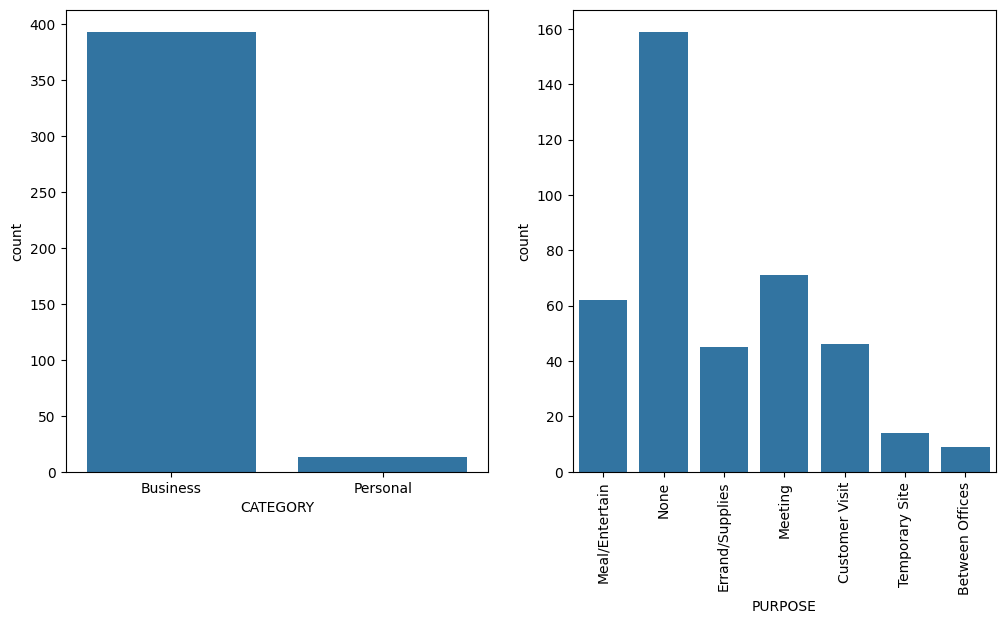

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.countplot(x=df['CATEGORY'])

plt.subplot(1,2,2)
sns.countplot(x=df['PURPOSE'])
plt.xticks(rotation=90)
plt.show()

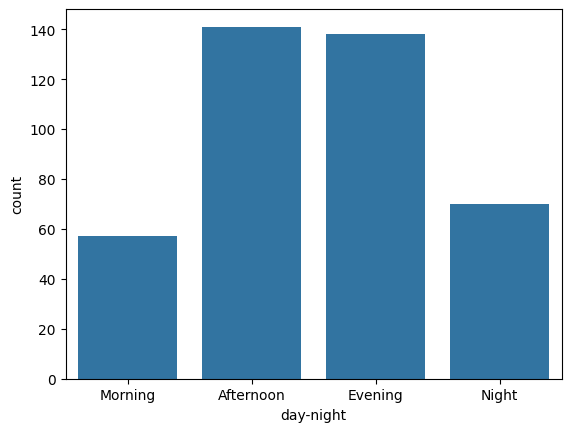

In [ ]:
sns.countplot(x=df['day-night'])
plt.show()

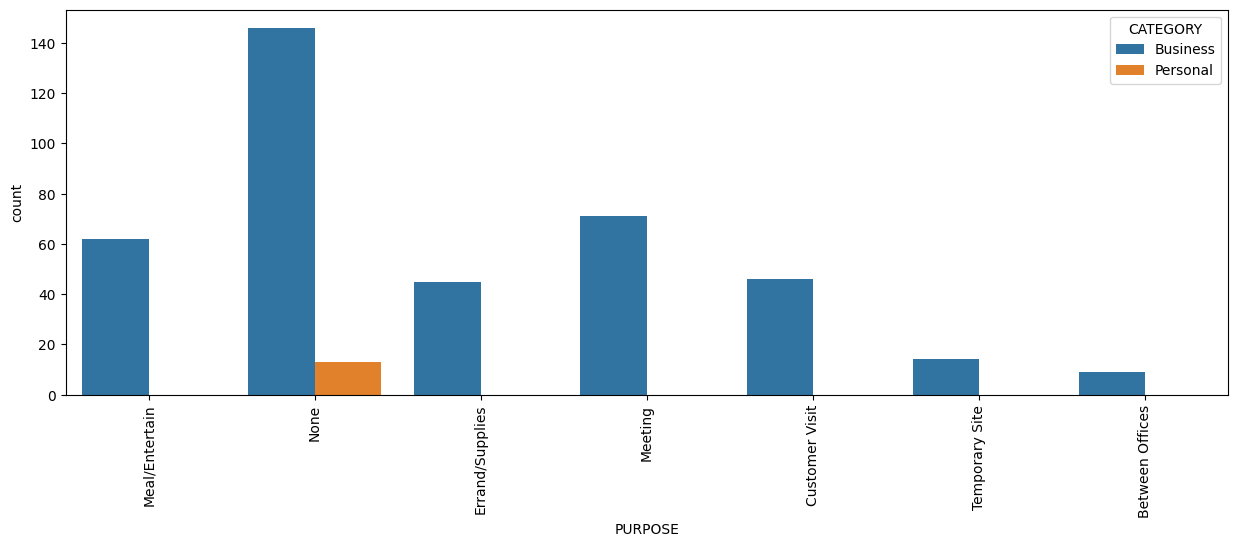

In [ ]:
plt.figure(figsize=(15, 5))
sns.countplot(x=df['PURPOSE'], hue=df['CATEGORY'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder
object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(df[object_cols]))
OH_cols.index = df.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = df.drop(object_cols, axis=1)
dataset = pd.concat([df_final, OH_cols], axis=1)

<Axes: >

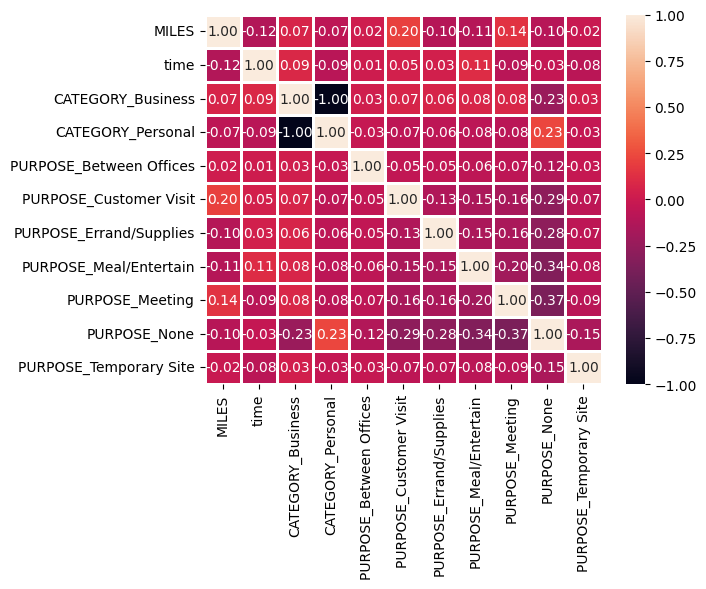

In [ ]:
numeric_dataset = dataset.select_dtypes(include=['number'])

sns.heatmap(numeric_dataset.corr(), annot=True, fmt='.2f', linewidths=2 )

[Text(0.5, 0, 'MONTHS'), Text(0, 0.5, 'VALUE COUNT')]

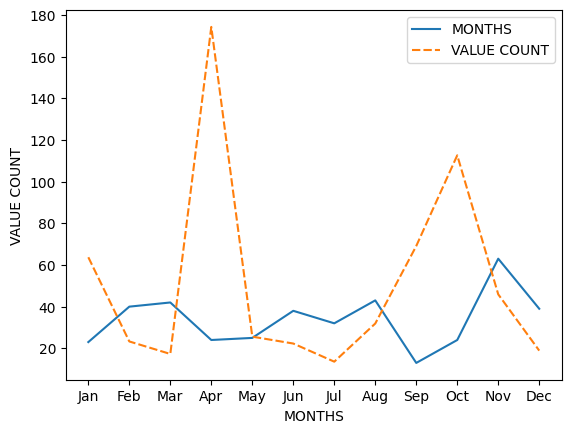

In [ ]:
dataset['MONTH'] = pd.DatetimeIndex(dataset['START_DATE']).month
month_label = {1.0:'Jan', 2.0:'Feb', 3.0:'Mar', 4.0:'Apr', 5.0:'May',
               6.0:'Jun', 7.0:'Jul', 8.0:'Aug', 9.0:'Sep', 10.0:'Oct',
               11.0:'Nov', 12.0:'Dec'}

dataset['MONTH'] = dataset.MONTH.map(month_label)
mon = dataset.MONTH.value_counts(sort=False)


ds = pd.DataFrame({"MONTHS": mon.values,
                   "VALUE COUNT": dataset.groupby('MONTH',
                                                  sort=False)['MILES'].max()})

p = sns.lineplot(data=ds)
p.set(xlabel="MONTHS", ylabel="VALUE COUNT")

In [ ]:
dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
dataset['DAY'] = dataset['DAY'].map(day_label)

Text(0, 0.5, 'COUNT')

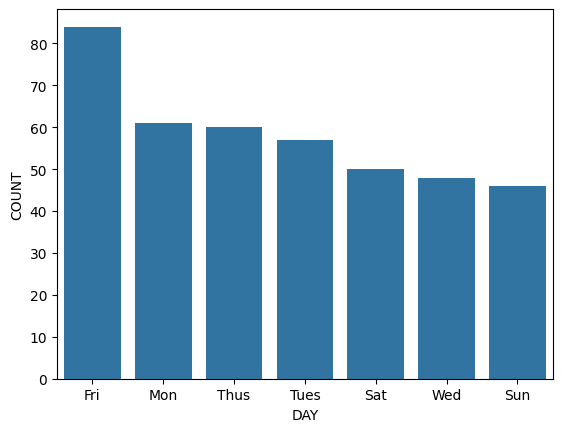

In [ ]:
day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')

<Axes: ylabel='MILES'>

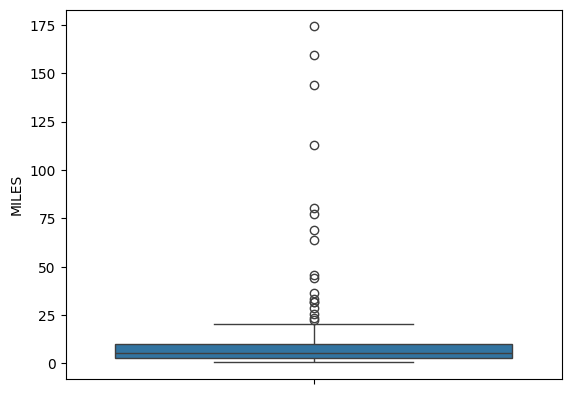

In [ ]:
sns.boxplot(dataset['MILES'])

<Axes: ylabel='MILES'>

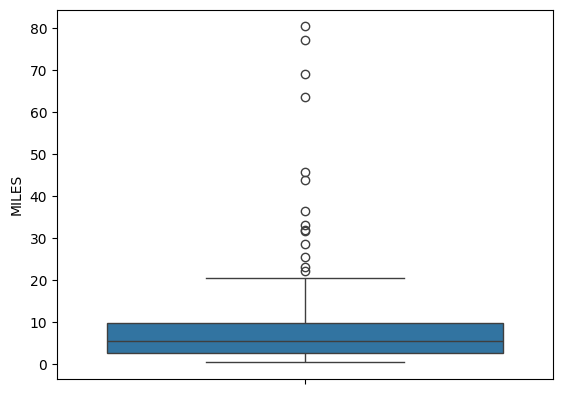

In [ ]:
sns.boxplot(dataset[dataset['MILES']<100]['MILES'])

<Axes: xlabel='MILES', ylabel='Count'>

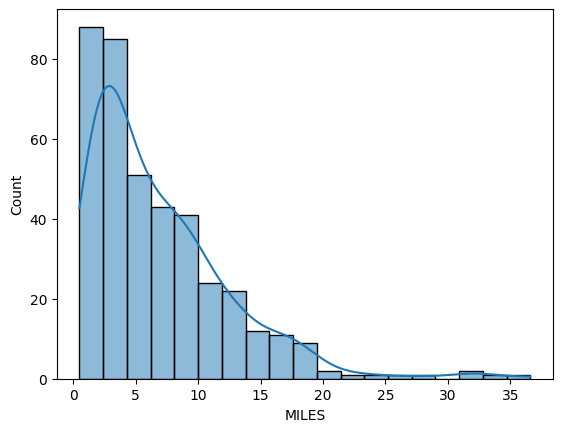

In [ ]:
sns.histplot(dataset[dataset['MILES']<40]['MILES'], kde=True)